In [9]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from job_items import JobItem
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from google.colab import userdata

## Auth

In [10]:
login(userdata.get('HF_TOKEN'), add_to_git_credential=True)

## Load your dataset

In [11]:
username = "toughfigure"
dataset = f"{username}/jobs_full"

train, val, test = JobItem.from_hub(dataset)
items = train + val + test
print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 2,797 training items, 155 validation items, 155 test items


In [14]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

## Token distribution of the raw summary (job description text)

In [13]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/3107 [00:00<?, ?it/s]

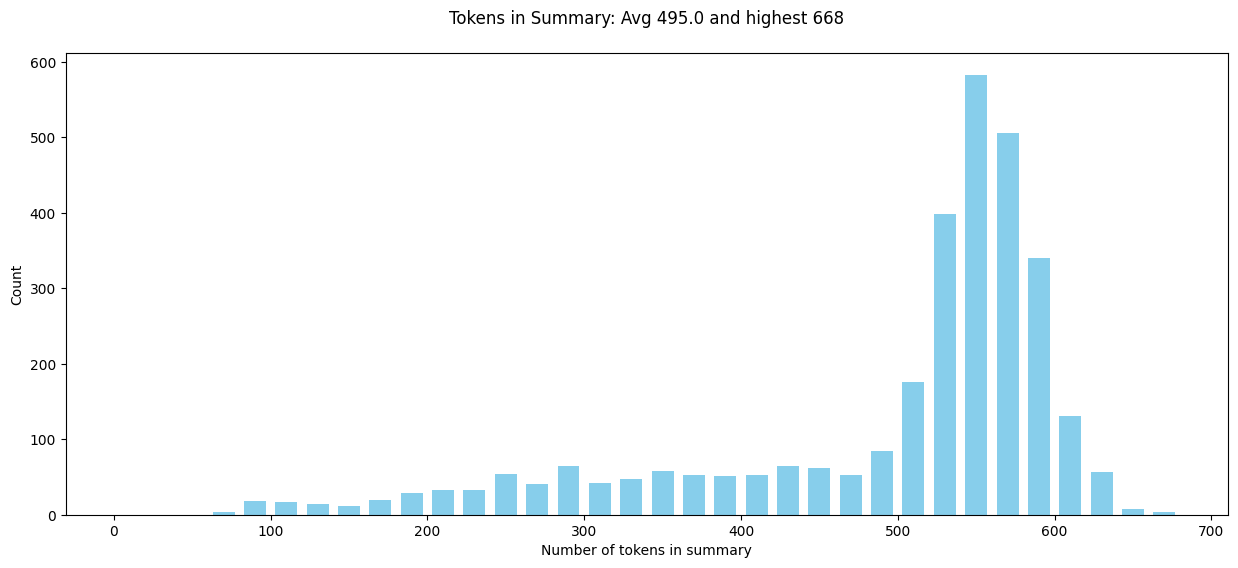

In [16]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 700, 20))
plt.show()

In [17]:
CUTOFF = 600
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")

With this CUTOFF, we will truncate 194 items which is 6.2%


## Sanity check a raw summary

In [18]:
print(train[0].summary)

Job Title: Service Now Engineer
Company: BAE Systems, Inc.
Location: Sterling, VA



Job Description



Job Description Innovative, Creative, Trusted! Are you ready to join a team that exhibits all of these qualities and more?! Join BAE Systems Intelligence & Security (I&S) Sector and be a part of an agile team that protects and supports those who protect us. Our team is looking for an analytical, talented and motivated Service Now Engineer to develop, engineer and optimize a new Digital Engineering Ecosystem (DEE) by leveraging automation capabilities within Service Now. As a Service Now Engineer, you may:

Design, develop, document, test, and debug the configurations and workflows in Service NowAnalyze and develop capabilities in alignment with defined user stories and acceptance criteriaApply DevOps experience in activities including version control, automated builds, automated testing, and continuous integrationIntegrates solutions within the PlatformIdentifies/develops solutions f

## Build prompts (train/val get the completion baked in; test withholds it)

In [19]:
for item in tqdm(train + val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/2952 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  0%|          | 0/155 [00:00<?, ?it/s]

## Sanity check a built prompt/completion pair

In [21]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)

PROMPT:
What is the estimated annual salary in USD for this role?

<|begin_of_text|>Job Title: Transportation Engineer II
Company: Metropolitan Washington Council of Governments
Location: Washington DC-Baltimore Area

DescriptionThe Department of Transportation Planning of the Metropolitan Washington Council of Governments (COG) seeks a Transportation Engineer II to assist in professional-level planning activities that support metropolitan transportation planning with a focus on roadway safety and freight planning. The transportation engineer position, as part of the Systems Performance Planning Team, will primarily play a role in providing technical analysis to inform decision-making on regional roadway safety and freight planning issues, with some support of pedestrian and bicycle planning. The successful candidate will also have broader responsibilities including facilitating regional coordination and communication, authoring technical reports on metropolitan transportation issues, 

## Full prompt+completion token distribution

In [22]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/3107 [00:00<?, ?it/s]

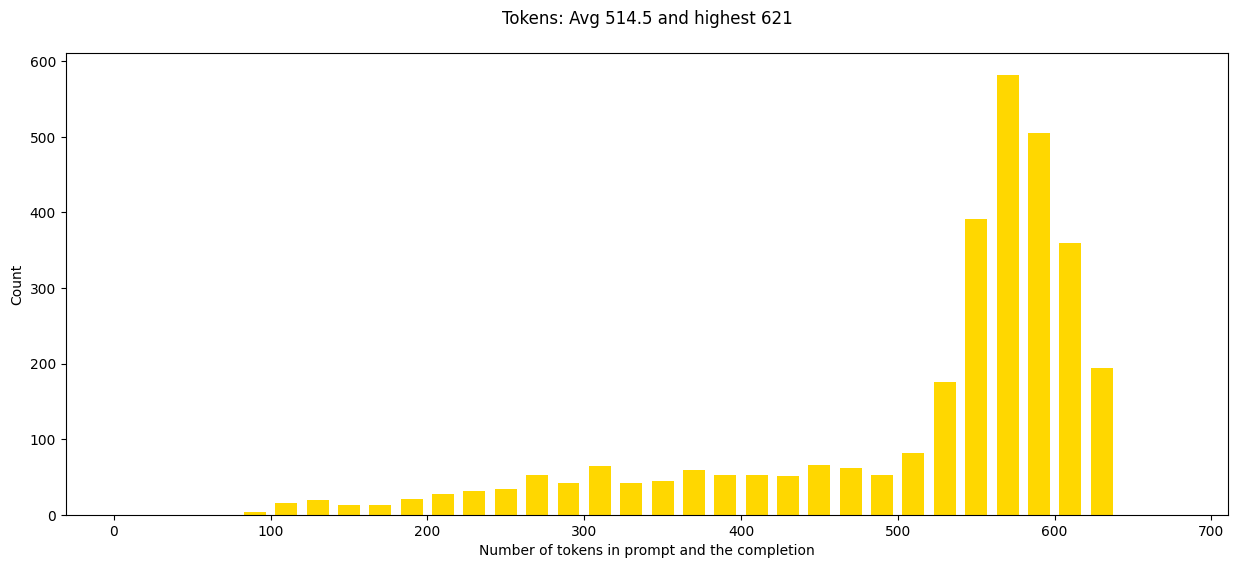

In [23]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 700, 20))
plt.show()

In [24]:
dataset = f"{username}/jobs_prompts_full"
JobItem.push_prompts_to_hub(dataset, train, val, test)
print("Done. jobs_prompts_full is ready for fine-tuning.")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  12%|#2        |  525kB / 4.25MB            

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  251kB /  251kB            

Done. jobs_prompts_full is ready for fine-tuning.
